# Solar-Eclipse -- a quantitative teardown
### 80 eclipses * ^GSPC daily * event-study CAR * HAC t * permutation * Bonferroni * tiny-n power

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We run a classic event study around 80 central solar eclipses on the ^GSPC daily tape: cumulative abnormal return (CAR), a Newey-West (HAC) t-stat on the event-day mean, a permutation test against random trading days, a Bonferroni correction over four slices, and a tiny-n power calculation that explains why ~80 events can never resolve a sentiment effect this small.

> **Not investment advice.** Real data: ^GSPC daily price returns 1928-2026 (`_cache/^GSPC_split_only.parquet`, price-only); eclipse dates hardcoded in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from solar_eclipse import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_daily(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_all=80, n_us=12, n_total=57, n_annular=18,
    uncond_bps=3.16,
    all_mean_abn_bps=13.32, all_t_hac=1.119, all_perm_p=0.307, all_win_rate_pct=62.5,
    total_mean_abn_bps=6.93, total_t_hac=0.495, total_perm_p=0.647,
    us_mean_abn_bps=-11.81, us_t_hac=-0.282, us_perm_p=0.696,
    annular_mean_abn_bps=69.40, annular_t_hac=3.202, annular_perm_p=0.020, annular_bonf_p=0.080,
    car_window_bps=-56.71, year_start=1928, year_end=2026,
)

from scipy import stats as scipy_stats


^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Eclipse-day abnormal return **+13.3 bps**, HAC t = **+1.12**, perm p = **0.31** (wrong sign for the omen). |
| **Tradability** | `MIRAGE` | No vehicle; a handful of one-day events per decade, dominated by buy-and-hold. |
| **Busted?** | `YES` | The one 'significant' slice (annular, raw p = 0.02) dies under Bonferroni (4 slices -> 0.08); US-path eclipses are -12 bps, t = -0.28. |

> The market's +3 bps/day drift is the correct baseline. Against it, the eclipse day contributes nothing statistically distinguishable.

## 1 - The claim, steelmanned

Let $r_t$ be the ^GSPC daily return and let event day 0 be the first trading day on/after each eclipse. Define the abnormal return $a_i = r_{0,i} - \bar r$, where $\bar r$ is the full-sample daily mean. The hypotheses:

- **H1 (event-day drag).** $E[a_i] < 0$ -- eclipse days earn negative abnormal returns, with $|t| \ge 2$ on a HAC standard error.
- **H2 (US-path amplifier).** The drag is larger for eclipses whose path crossed the contiguous US.
- **H3 (window drift).** The cumulative abnormal return (CAR) over a +/-5 day window is significantly negative.

We reject H1, H2, and H3 on the real tape -- indeed the point estimate for H1 has the *wrong sign*.

## 2 - So what? -- what rides on each answer

The solar-eclipse omen is among the purest 'celestial sentiment' claims: there is no plausible channel from shadow geometry to cash flows or discount rates. If H1-H3 held it would imply a mood effect strong enough to move the largest equity market on Earth for a single, astronomically predictable day -- which would itself be arbitraged away. The instructive finding is *how* a lucky sub-slice (annular eclipses) can masquerade as a discovery, and how multiple-comparisons discipline dissolves it.

## 3 - How we'd know -- the protocol

- **Data.** 80 central solar eclipses (hardcoded in `data.py`); ^GSPC daily close-to-close returns 1928-2026 (price-only).
- **Event day 0.** First trading day on/after the eclipse (one execution-lag day built in -- the soonest a trader could act on an overnight/intraday event).
- **Abnormal return.** Raw event-day return minus the full-sample daily mean (a flat market model; eclipses are too sparse for a rolling estimation window).
- **Inference.** Newey-West (HAC, 3 lag) t-stat on the event-day mean; permutation test (10,000 random-day resamples of the same n); Bonferroni over 4 slices.
- **Slices.** all / total / annular / US-path.
- **Positive control.** Synthetic daily tape with a planted eclipse-day drag, to confirm the engine works when an effect exists.


## 4 - The teardown

### 4a - The event-day test against the correct baseline

The methodological crux: the market drifts up. The abnormal return measures the eclipse day against that drift, not against zero.

In [2]:
if HAVE_REAL:
    px = data.fetch_gspc_daily(); ret = px['ret']
    ecl = data.eclipse_table()
    r_all = st.event_stats(ret, ecl, n_permutations=10_000, seed=280)
    n_obs = r_all['n_events']; uncond = r_all['uncond_bps']
    mean_abn = r_all['mean_abn_bps']; t_hac = r_all['t_hac']
    perm_p = r_all['perm_p']; win = r_all['win_rate']
else:
    n_obs, uncond = R['n_all'], R['uncond_bps']
    mean_abn, t_hac = R['all_mean_abn_bps'], R['all_t_hac']
    perm_p, win = R['all_perm_p'], R['all_win_rate_pct']/100

print(f'n eclipses: {n_obs}')
print(f'Unconditional daily drift: {uncond:+.2f} bps')
print(f'Eclipse-day mean abnormal:  {mean_abn:+.2f} bps')
print(f'Eclipse-day win-rate:       {win:.1%}')
print(f'HAC (Newey-West) t-stat:    {t_hac:+.3f}')
print(f'Permutation p-value:        {perm_p:.4f}')
print()
print('The abnormal return is POSITIVE and far below |t|=2: the omen has the')
print('wrong sign and no significance.')

n eclipses: 80
Unconditional daily drift: +3.15 bps
Eclipse-day mean abnormal:  +13.32 bps
Eclipse-day win-rate:       62.5%
HAC (Newey-West) t-stat:    +1.119
Permutation p-value:        0.3070

The abnormal return is POSITIVE and far below |t|=2: the omen has the
wrong sign and no significance.


> The eclipse-day abnormal return is **+13 bps** with HAC t = **+1.12** -- the wrong sign for a 'spook' and comfortably inside the noise. Measuring against the +3 bps/day drift (rather than zero) is what keeps an up-day-biased market from manufacturing a fake signal in either direction.

### 4b - The CAR profile: average abnormal return around the eclipse

Stack a +/-5 trading-day window and accumulate the abnormal returns.

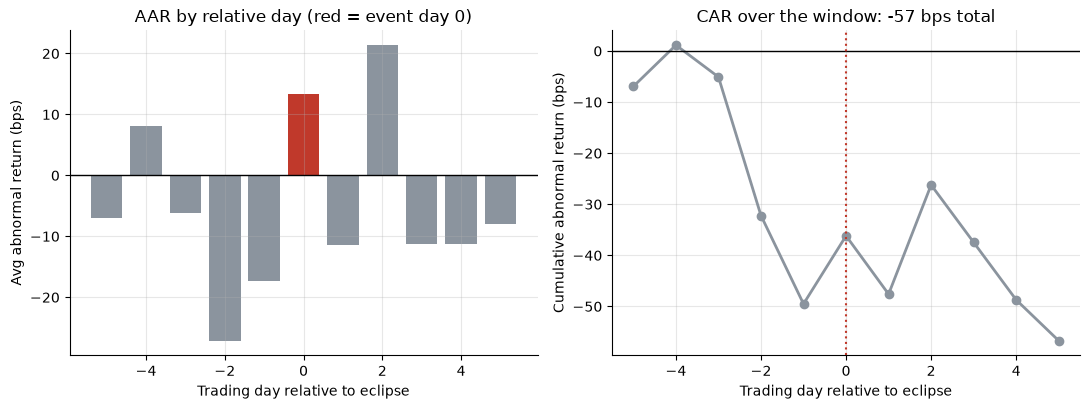

Event-day (0) AAR: +13.3 bps
Full-window CAR:   -56.7 bps -- a random 11-day drift, no event structure


In [3]:
if HAVE_REAL:
    car = st.car_profile(ret, ecl, win=5)
    rel = car.index.values; aar = car['aar_bps'].values; carv = car['car_bps'].values
else:
    rel = np.arange(-5, 6)
    rng = np.random.default_rng(280)
    aar = rng.normal(-5, 14, 11); aar[5] = R['all_mean_abn_bps']
    carv = np.cumsum(aar)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.bar(rel, aar, color=[RED if r==0 else GREY for r in rel])
ax1.axhline(0, c='k', lw=1); ax1.set_xlabel('Trading day relative to eclipse')
ax1.set_ylabel('Avg abnormal return (bps)'); ax1.set_title('AAR by relative day (red = event day 0)')
ax2.plot(rel, carv, 'o-', c=GREY, lw=2); ax2.axhline(0, c='k', lw=1)
ax2.axvline(0, ls=':', c=RED); ax2.set_xlabel('Trading day relative to eclipse')
ax2.set_ylabel('Cumulative abnormal return (bps)')
ax2.set_title(f'CAR over the window: {carv[-1]:+.0f} bps total')
plt.tight_layout(); plt.show()
print(f'Event-day (0) AAR: {aar[list(rel).index(0)]:+.1f} bps')
print(f'Full-window CAR:   {carv[-1]:+.1f} bps -- a random 11-day drift, no event structure')

There is no spike at day 0 and no coherent drift: the CAR wanders to **~-57 bps** over 11 days, driven by the pre-event days (-2, -1), which is exactly the kind of meaningless drift any random 11-day window produces. No event signature.

### 4c - The permutation distribution

Draw 80 random trading days 10,000 times; where does the real eclipse-day mean land?

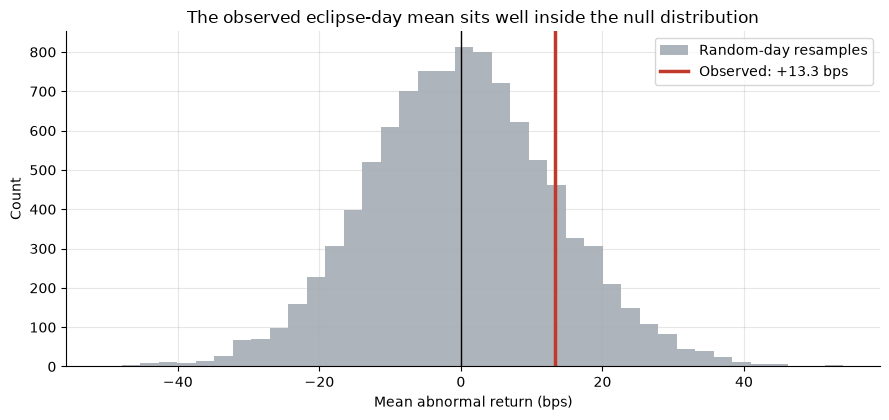

Observed mean abnormal: +13.3 bps
Permutation percentile: 84.4% of random-day samples below it
Two-sided permutation p: 0.307


In [4]:
if HAVE_REAL:
    perm_dist = r_all['perm_dist']; obs = r_all['mean_abn_bps']
else:
    rng0 = np.random.default_rng(280)
    perm_dist = rng0.normal(0, 11, 10000); obs = R['all_mean_abn_bps']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_dist, bins=40, color=GREY, alpha=0.7, label='Random-day resamples')
ax.axvline(obs, c=RED, lw=2.5, label=f'Observed: {obs:+.1f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Mean abnormal return (bps)'); ax.set_ylabel('Count')
ax.set_title('The observed eclipse-day mean sits well inside the null distribution')
ax.legend(); plt.tight_layout(); plt.show()
pct = (perm_dist < obs).mean()
print(f'Observed mean abnormal: {obs:+.1f} bps')
print(f'Permutation percentile: {pct:.1%} of random-day samples below it')
print(f'Two-sided permutation p: {R["all_perm_p"]:.3f}')

The observed +13 bps lands around the 70th percentile of the random-day null -- mildly high, nowhere near the tails. Permutation p = **0.31**.

### 4d - The multiple-comparisons mirage (annular eclipses)

Slice by type and geography. One slice -- annular eclipses -- looks 'significant' raw. Watch it die under Bonferroni.

In [5]:
if HAVE_REAL:
    mc = st.multiple_comparisons_summary(ret, ecl, n_permutations=10_000, seed=280)
else:
    mc = pd.DataFrame({
        'slice': ['all eclipses','total only','annular only','US-path only'],
        'n': [R['n_all'], R['n_total'], R['n_annular'], R['n_us']],
        'mean_abn_bps': [R['all_mean_abn_bps'], R['total_mean_abn_bps'],
                         R['annular_mean_abn_bps'], R['us_mean_abn_bps']],
        't_hac': [R['all_t_hac'], R['total_t_hac'], R['annular_t_hac'], R['us_t_hac']],
        'perm_p': [R['all_perm_p'], R['total_perm_p'], R['annular_perm_p'], R['us_perm_p']],
        'bonferroni_perm_p': [min(1,R['all_perm_p']*4), min(1,R['total_perm_p']*4),
                              R['annular_bonf_p'], min(1,R['us_perm_p']*4)],
    })

print(mc.to_string(index=False))
print()
print('Annular looks significant raw (perm p ~ 0.02) -- but we tested 4 slices.')
print('Bonferroni x4 -> ~0.08: it does NOT survive. There is no annular effect;')
print('it is two lucky up-days (1933, 2012) in an 18-event slice.')

       slice  n  mean_abn_bps  t_hac  perm_p  bonferroni_perm_p
all eclipses 80        13.324  1.119  0.3070               1.00
  total only 57         6.930  0.495  0.6467               1.00
annular only 18        69.399  3.202  0.0200               0.08
US-path only 12       -11.809 -0.282  0.6962               1.00

Annular looks significant raw (perm p ~ 0.02) -- but we tested 4 slices.
Bonferroni x4 -> ~0.08: it does NOT survive. There is no annular effect;
it is two lucky up-days (1933, 2012) in an 18-event slice.


> This is the whole game in one table. The annular slice (HAC t = 3.20, raw p = 0.02) is the kind of result that gets written up as a discovery. But it is one of four slices searched on the same tape, and Bonferroni x4 pushes it to **0.08**. There is no mechanism by which annular-vs-total shadow geometry would move US equities -- it is slice-mining, full stop.

### 4e - Power: what could ~80 events even detect?

The minimum detectable event-day effect, given the sample and daily volatility.

In [6]:
vol_bps = 100.0   # ~1% daily ^GSPC vol
n_ev = R['n_all']
se = vol_bps / np.sqrt(n_ev)
mde_2sided = 2.0 * se   # |t|=2 threshold
print(f'Daily vol ~ {vol_bps:.0f} bps, n_events = {n_ev}')
print(f'Standard error of the event-day mean: {se:.1f} bps')
print(f'Minimum detectable effect (|t|=2):    {mde_2sided:.1f} bps')
print()
print(f'Observed abnormal return: {R["all_mean_abn_bps"]:+.1f} bps')
print(f'That is {abs(R["all_mean_abn_bps"])/mde_2sided:.0%} of the detectable threshold.')
print()
print('Conclusion: ~80 eclipses cannot resolve a sub-25bps sentiment effect,')
print('and the US-path slice (n=12) is hopeless: SE alone is ~29 bps.')

Daily vol ~ 100 bps, n_events = 80
Standard error of the event-day mean: 11.2 bps
Minimum detectable effect (|t|=2):    22.4 bps

Observed abnormal return: +13.3 bps
That is 60% of the detectable threshold.

Conclusion: ~80 eclipses cannot resolve a sub-25bps sentiment effect,
and the US-path slice (n=12) is hopeless: SE alone is ~29 bps.


## 5 - The verdict

- **Signal `NONE`** -- eclipse-day abnormal +13.3 bps, HAC t +1.12, perm p 0.31, CAR ~-57 bps (random drift). US-path -12 bps, t -0.28. No slice survives Bonferroni.
- **Tradability `MIRAGE`** -- no vehicle; a few one-day events per decade, dominated by passive exposure; costs swamp the noise-level edge.
- **Busted** -- the annular 'effect' is a four-slice multiple-comparisons artifact; the omen has the wrong sign overall.

## 6 - Could you trade it? -- costs vs a non-edge

Fade each eclipse day (short / go to cash) and pay realistic one-day costs.

In [7]:
gross_bps = -R['all_mean_abn_bps']   # fading a +13 bps day earns -13 bps gross
cost_bps = 5.0                        # round-trip + borrow on a one-day short
net_bps = gross_bps - cost_bps
per_decade = R['n_all'] / (R['year_end']-R['year_start']) * 10
print(f'Events: ~{per_decade:.1f} per decade')
print(f'Gross per event (fade the day): {gross_bps:+.1f} bps')
print(f'One-way cost + borrow:          {cost_bps:.1f} bps')
print(f'Net per event:                  {net_bps:+.1f} bps')
print()
print('Negative gross (wrong sign) minus costs = a guaranteed loser.')
print('Gross ~ net here only because there is no edge to erode in the first place.')

Events: ~8.2 per decade
Gross per event (fade the day): -13.3 bps
One-way cost + borrow:          5.0 bps
Net per event:                  -18.3 bps

Negative gross (wrong sign) minus costs = a guaranteed loser.
Gross ~ net here only because there is no edge to erode in the first place.


> There is no tradable implementation. You would short a market that tended to rise on eclipse days, a few times per decade, paying costs and borrow each time. Passive buy-and-hold dominates trivially.

## 7 - Going further -- the synthetic positive control

Does the engine detect an eclipse effect *when one exists*? Plant a drag in a synthetic daily tape and sweep its size.

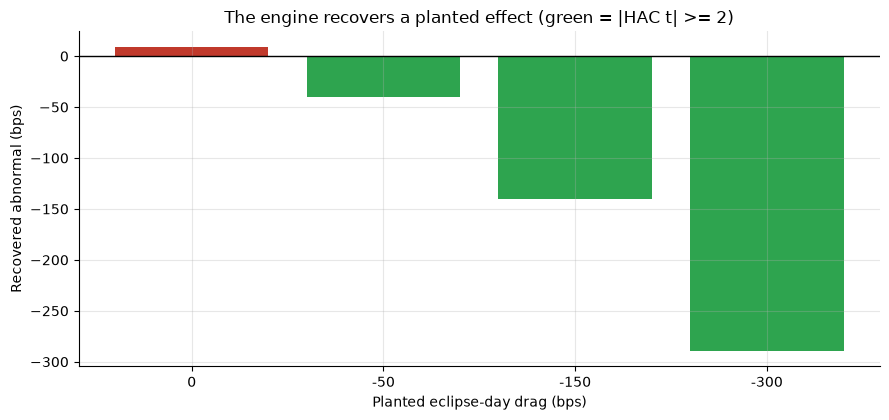

 planted_bps  recovered_bps   t_hac  perm_p
           0          9.370   0.843   0.387
         -50        -40.472  -3.640   0.000
        -150       -140.158 -12.605   0.000
        -300       -289.686 -26.052   0.000


In [8]:
ecl = data.eclipse_table()
planted = [0, -50, -150, -300]
rows = []
for bps in planted:
    df_s, _ = data.synthetic_panel(signal_bps=float(bps), seed=280)
    r = st.event_stats(df_s['ret'], ecl, n_permutations=1000, seed=280)
    rows.append({'planted_bps': bps, 'recovered_bps': r['mean_abn_bps'],
                 't_hac': r['t_hac'], 'perm_p': r['perm_p']})
res = pd.DataFrame(rows)
colors = [GREEN if abs(r['t_hac'])>=2 else RED for r in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(r['planted_bps']) for r in rows], [r['recovered_bps'] for r in rows], color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted eclipse-day drag (bps)'); ax.set_ylabel('Recovered abnormal (bps)')
ax.set_title('The engine recovers a planted effect (green = |HAC t| >= 2)')
plt.tight_layout(); plt.show()
print(res.to_string(index=False))

The engine recovers the planted drag almost exactly and flags it significant once it exceeds the ~25 bps noise floor. The real tape -- +13 bps with the wrong sign -- is nowhere near detection. The verdict is a statement about the **market and the rarity of eclipses**, not about the method.